In [1]:
from spin_lattices import KagomeLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import (
    BooleanFourierAnalyzer,
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    SignalOption,
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
)
from boolean_fourier_learner import BooleanFourierLearner

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse

from parity import popcount

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data

import pickle

ground_state_cache_dir = Path("groundstates")
fourier_learners_cache_dir = Path("fourier_learners_cache")
experiments_dir = Path("experiments") / "kagome-24-nn-2023-01-26"
experiments_dir.mkdir(parents=True, exist_ok=True)

2023-01-30 14:53:51.827 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-01-30 14:53:51.829 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-01-30 14:53:51.879 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [2]:
J2 = 1
system = HeisenbergJ1J2(
    lattice=KagomeLattice(width=2, height=4),
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=ground_state_cache_dir,
    show_progress=True,
)
system.get_eigenstates(1)


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


(array([-42.82459918]),
 array([[ 3.68841196e-07],
        [ 1.08484503e-07],
        [-6.80321312e-19],
        ...,
        [-1.41331442e-05],
        [-1.67384289e-02],
        [ 3.56623895e-02]]))

In [3]:
df = (
    system.get_df_ground_state(
        canonical_basis=True, unpack_configurations=True, expand_basis_columns=True
    )
    .assign(
        sign=(lambda df: np.sign(df["eigenstate_coeff"])),
        prob=(lambda df: np.abs(df["eigenstate_coeff"]) ** 2),
    )
    .assign(y=lambda df: (df["sign"] == 1).astype(int))
)


In [6]:
eps_train = 1e-2
val_eps = 1e-2
test_eps = 1e-2
batch_size = 64

df_train = df.sample(frac=eps_train, weights="prob")
df_val = df.drop(df_train.index).sample(frac=val_eps, weights="prob")
df_test = df.drop(df_train.index).drop(df_val.index).sample(frac=test_eps, weights="prob")

n_batches = int(np.ceil(len(df_train) / batch_size))
epochs = 20000


In [7]:
net = nn.Sequential(
    nn.Linear(system.number_spins, 64),
    nn.ReLU(),
    nn.Linear(64, 2),
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
features = [f"s{i}" for i in range(system.number_spins)]


In [8]:
def get_inputs_and_labels(df: pd.DataFrame) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    X = torch.tensor(df[features].values.astype("float"), dtype=torch.float32)
    y = torch.tensor(df["y"].values.astype("int8"), dtype=torch.long)
    probs = torch.tensor(df["prob"].values.astype("float"), dtype=torch.float32)
    return X, y, probs


inputs_val, labels_val, probs_val = get_inputs_and_labels(df_val)


In [9]:
def evaluate(net, inputs, labels, probs):
    with torch.no_grad():
        outputs = net(inputs)
        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().item()
        accuracy = correct / len(labels)

        sign_overlap = (
            ((predicted * 2 - 1) * (labels * 2 - 1) * probs).sum() / probs.sum()
        ).item()
        return accuracy, sign_overlap


In [11]:
pd.Series(1, index=[1, 2, 3])

1    1
2    1
3    1
dtype: int64

In [10]:
for epoch in range(epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    i = None
    loss = None

    for i in range(n_batches):
        data = df_train.iloc[i * batch_size : (i + 1) * batch_size]
        inputs, labels, probs = get_inputs_and_labels(data)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f"[{epoch + 1}, {i}] loss: {loss}")

    accuracy, sign_overlap = evaluate(net, inputs, labels, probs)
    print(f"Test set: accuracy: {100 * accuracy} %, sign overlap: {sign_overlap}")

    accuracy_val, sign_overlap_val = evaluate(net, inputs_val, labels_val, probs_val)
    print(f"Validation set: accuracy: {100 * accuracy_val} %, sign overlap: {sign_overlap_val}")


[1, 422] loss: 0.6904836893081665
Test set: accuracy: 52.94117647058824 %, sign overlap: 0.44829535484313965
Validation set: accuracy: 49.67315378581301 %, sign overlap: -0.003512777853757143
[2, 422] loss: 0.6884921789169312
Test set: accuracy: 52.94117647058824 %, sign overlap: 0.39620354771614075
Validation set: accuracy: 49.441559896903364 %, sign overlap: -0.013233446516096592
[3, 422] loss: 0.6860566139221191
Test set: accuracy: 61.76470588235294 %, sign overlap: 0.5484927892684937
Validation set: accuracy: 49.58723992379814 %, sign overlap: -0.010927289724349976
[4, 422] loss: 0.6843504309654236
Test set: accuracy: 67.64705882352942 %, sign overlap: 0.5898154377937317
Validation set: accuracy: 49.46770759403832 %, sign overlap: -0.014100481756031513
[5, 422] loss: 0.6819084882736206
Test set: accuracy: 70.58823529411765 %, sign overlap: 0.611156702041626
Validation set: accuracy: 49.583504538493145 %, sign overlap: -0.022782912477850914
[6, 422] loss: 0.6819617748260498
Test set

KeyboardInterrupt: 

In [113]:
analyzer = BooleanFourierAnalyzer(
    system=system,
    use_subset_symmetries=True,
    show_progress=True,
    cache_dir=fourier_learners_cache_dir,
)


Making Fourier basis state info with symmetries...
MFBSIS: Building Fourier basis...
MFBSIS: Computing state info...


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


MFBSIS: Computing sign flip basis correspondence...
MFBSIS: Computing fourier_basis_state_info_df...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763


In [114]:
analyzer.fit(
    analyzer.system.canonical_basis.states, signal_opt=SignalOption(kind=SignSignalKind())
)


Restoring learner from cache: fourier_learners_cache/485a7e675a16d4a5bd22ed3c02de8f6f-HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz


<AxesSubplot: >

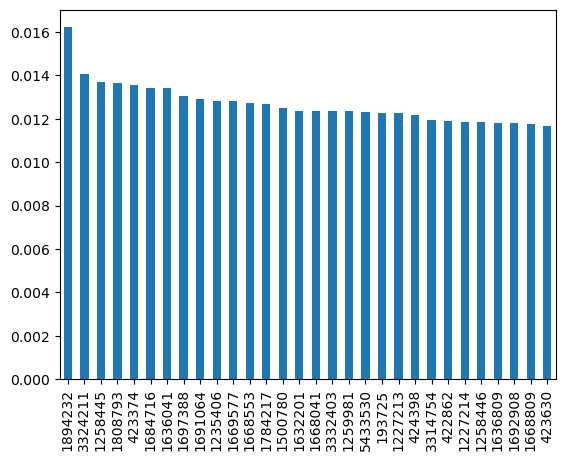

In [118]:
np.abs(analyzer.learner.get_coeffs_ser().iloc[:30]).plot.bar()


In [120]:
nn_fourier_learner = BooleanFourierLearner(system.number_spins, analyzer.subsets)


In [121]:
full_inputs, _, _ = get_inputs_and_labels(df)


In [125]:
with torch.no_grad():
    nn_full_prediction = torch.max(net(full_inputs), 1)[1].numpy()


In [1]:
nn_full_prediction

NameError: name 'nn_full_prediction' is not defined

In [128]:
df.index


UInt64Index([    4095,     6143,     7167,     7679,     7935,     8063,
                 8127,     8159,     8175,     8183,
             ...
             16769032, 16769040, 16769056, 16769088, 16769152, 16769280,
             16769536, 16770048, 16771072, 16773120],
            dtype='uint64', length=2704156)

In [129]:
nn_fourier_learner.fit(
    np.asarray(df.index, dtype="uint64"),
    nn_full_prediction * 2 - 1,
    batch_size=1000,
    show_progress=True,
)


100%|██████████| 2705/2705 [1:15:18<00:00,  1.67s/it]


<AxesSubplot: >

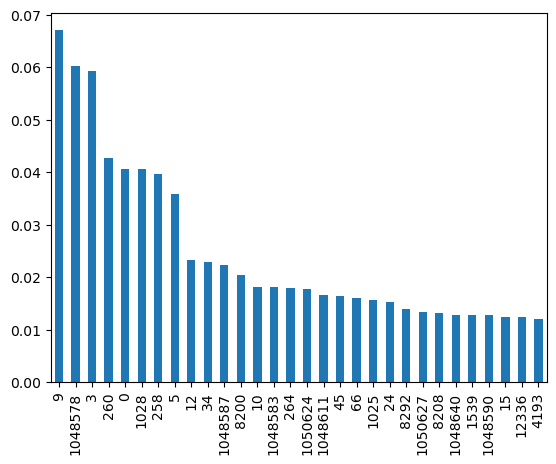

In [130]:
np.abs(nn_fourier_learner.get_coeffs_ser().iloc[:30]).plot.bar()


In [132]:
popcount(np.asarray(nn_fourier_learner.get_coeffs_ser().iloc[:30].index, dtype="uint64"))

array([2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 4, 2, 2, 4, 2, 2, 4, 4, 2, 2, 2, 4,
       4, 2, 2, 4, 4, 4, 4, 4], dtype=uint8)

In [133]:
nn_fourier_learner.get_coeffs_ser()

9          0.067073
1048578    0.060150
3          0.059258
260       -0.042638
0          0.040637
             ...   
1182759    0.000000
287543     0.000000
1190865    0.000000
1059010    0.000000
1443698    0.000000
Name: coeff, Length: 264976, dtype: float64

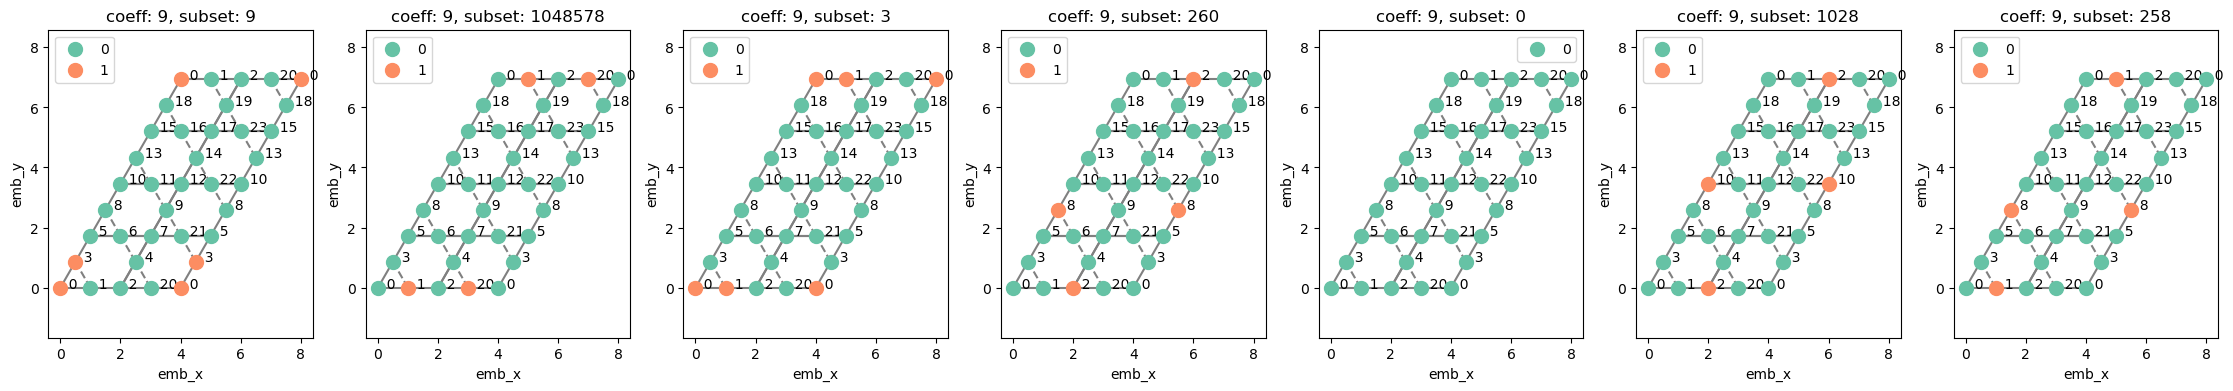

In [140]:
fix, ax = plt.subplots(ncols=7, figsize=(7 * 4, 4))
for i, subset in enumerate(nn_fourier_learner.get_coeffs_ser().iloc[:7].index):
    ax[i].set_title(f"coeff: {coeff}, subset: {subset}")
    analyzer.system.lattice.plot(spins=subset, ax=ax[i])

In [145]:
with open(experiments_dir / "nn_fourier_learner.pkl", "wb") as f:
    pickle.dump(nn_fourier_learner, f)

In [146]:
torch.save(net.state_dict(), experiments_dir / "nn_model.pt")